# 목표

뉴스의 카테고리 예측

In [18]:
# %load_ext colablinter

In [19]:
import os

ROOT_DIR = os.getcwd()
TRAIN_DIR = os.path.join(ROOT_DIR, "data", "20news-bydate-train")
TEST_DIR = os.path.join(ROOT_DIR, "data", "20news-bydate-test")

In [20]:
train_category_set = set(os.listdir(TRAIN_DIR))
test_category_set = set(os.listdir(TEST_DIR))

only_in_train = train_category_set - test_category_set
only_in_test = test_category_set - train_category_set

print(f"· 학습 데이터에만 있는 카테고리: {len(only_in_train)}개")
print(f"· 테스트 데이터에만 있는 카테고리: {len(only_in_test)}개")

· 학습 데이터에만 있는 카테고리: 0개
· 테스트 데이터에만 있는 카테고리: 0개


In [21]:
import io
from glob import glob

TRAIN_DICT = dict()

paths = glob(os.path.join(TRAIN_DIR, "**"), recursive=True)

for path_ in paths:
    if os.path.isfile(path_):
        with open(path_, "r", encoding="utf-8") as f:
            if type(f) == io.TextIOWrapper:
                category = os.path.dirname(path_).split("/")[-1]
                if category in TRAIN_DICT.keys():
                    TRAIN_DICT[category].append(path_)
                else:
                    TRAIN_DICT[category] = [path_]

In [34]:
TRAIN_DICT = dict()
TEST_DICT = dict()

for category in os.listdir(TRAIN_DIR):
    TRAIN_DICT[category] = [path_ for path_ in glob(os.path.join(TRAIN_DIR, category, "*")) if os.path.isfile(path_)]

for category in os.listdir(TEST_DIR):
    TEST_DICT[category] = [path_ for path_ in glob(os.path.join(TEST_DIR, category, "*")) if os.path.isfile(path_)]

print(f"· 학습 데이터: {sum([len(a) for a in TRAIN_DICT.values()])}개")
print(f"· 테스트 데이터: {sum([len(a) for a in TEST_DICT.values()])}개")

· 학습 데이터: 11314개
· 테스트 데이터: 7532개


학습 데이터에 비해 테스트 데이터가 너무 많은 듯?

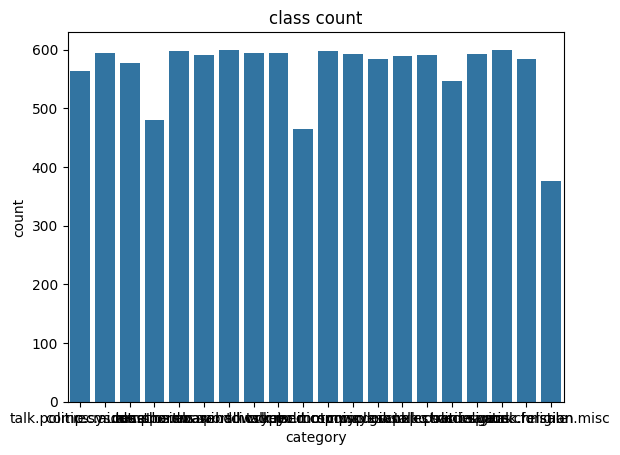

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class_df = pd.DataFrame(columns=["category", "count"])

for key, value in TRAIN_DICT.items():
    class_df.loc[len(class_df)] = [key, len(value)]

sns.barplot(data=class_df, x="category", y="count")
plt.title("class count")
plt.show()

In [37]:
print("[클래스별 데이터 개수]")

i = 0
for key, value in TRAIN_DICT.items():
    i += 1
    print(f"{i}) {key}: {len(value)}개")

[클래스별 데이터 개수]
1) talk.politics.mideast: 564개
2) rec.autos: 594개
3) comp.sys.mac.hardware: 578개
4) alt.atheism: 480개
5) rec.sport.baseball: 597개
6) comp.os.ms-windows.misc: 591개
7) rec.sport.hockey: 600개
8) sci.crypt: 595개
9) sci.med: 594개
10) talk.politics.misc: 465개
11) rec.motorcycles: 598개
12) comp.windows.x: 593개
13) comp.graphics: 584개
14) comp.sys.ibm.pc.hardware: 590개
15) sci.electronics: 591개
16) talk.politics.guns: 546개
17) sci.space: 593개
18) soc.religion.christian: 599개
19) misc.forsale: 585개
20) talk.religion.misc: 377개


talk.religion.misc 클래스가 좀 적네

In [ ]:
def get_text(path):
    with open(path, "r", encoding="utf-8") as f:
        data = f.read()
        
    return data

In [49]:
import random

rand_key_idx = random.randint(1, len(TRAIN_DICT.keys()))
rand_key = list(TRAIN_DICT.keys())[rand_key_idx - 1]
rand_value_idx = random.randint(1, len(TRAIN_DICT[rand_key]))

sample_text = get_text(TRAIN_DICT[rand_key][rand_value_idx - 1])

print(f"[샘플 출력 (label: {rand_key})]")
print("=" * 20)
print(sample_text)

[샘플 출력 (label: soc.religion.christian)]
From: mhsu@lonestar.utsa.edu (Melinda . Hsu   )
Subject: Re: The arrogance of Christians
Organization: University of Texas at San Antonio
Lines: 26

>They believe the danger is real, but others may not.
>
>Does that mean that the first group are NECESSARILY arrogant in warning
>others of the danger? Does it mean that they are saying that their beliefs
>are correct, and all others are false?
>
>Some might indeed react to opposition with arrogance, and behave in an
>arrogant manner, but that is a personal idiocyncracy. It does not
>necessarily mean that they are all arrogant.

No the members of the first group are not necessarily
arrogant.  But when I ask them if they are absolutely certain
that the volcano will erupt, I expect them to say so "No,
but I've chosen to believe some knowledgable people who have
determined that the volcano will erupt," rather than, "Yes, I am
absolutely certain."  When it comes to religious discussions,
arrogance or at 

1. '>' 같은 기호들 (단, 부등호는 조심할 것)

2. 연락처 같은 것들로 카테고리를 외운다면, 정답은 잘 맞추겠지만 과적합일 가능성이 높아질 것 같다.

3. 이메일도 지우자.
